# Money Craft Project: EDA and SCV Table Creation

### Accounts

One row per customer per active month. An account has closed (churned) when its rows stop — there is no churn column.

| column | description |
|---------------|--------------------------|
| customer_id |	Unique customer identifier. |
| month |	Calendar month, e.g. 2023-04. |
| acquisition_channel |	How the customer was won: Branch, Online, Comparison Site, Outbound, Referral or Broker/IFA. |
| region | UK region of the customer. |
| age_band | Customer age group. |
| account_tier | Packaged tier that month: Classic (£0), Silver (£11), Gold (£18) or Platinum (£28). Can change over time. |
| monthly_fee |	Fee charged that month (£). Zero on Classic, or while a fee-waiver promo is running. |
| joined_on_promo |	True if the customer joined on a 6-month fee-waiver promotion. |

### Closure

Recorded reasons for closed accounts — but only for some of them. This table is deliberately incomplete: many closures have no reason recorded.

| column |	description |
|--------|--------------|
| customer_id |	The customer who closed their account. |
| close_month |	Month the account was closed. |
| reason_code |	Recorded reason: Fees too high, Switched provider, Poor service, Unhappy with perks, Moved abroad, Bereavement or Unknown. |


### Spend

One row per month per channel: what we spent winning customers.

| column | description |
|--------|------------|
| month |	Calendar month. |
| channel	| Acquisition channel (matches acquisition_channel above). |
| spend_gbp |	Marketing spend in that channel that month (£). |



In [47]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [48]:
accounts = pd.read_csv('moneycraft_accounts.csv')

accounts.head()

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False
1,2,2022-01,Online,London,55-64,Silver,11,False
2,3,2022-01,Branch,South East,25-34,Platinum,28,False
3,4,2022-01,Referral,London,25-34,Silver,0,True
4,5,2022-01,Comparison Site,South East,35-44,Silver,11,False


## Account nulls

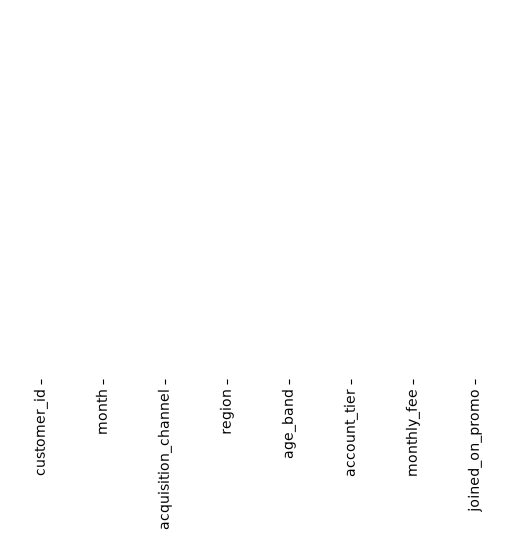

In [49]:
# any nulls/NaNs will appear as black lines
sns.heatmap(accounts.isnull(), yticklabels=False, cbar=False, cmap="gray_r");

In [50]:
accounts.info()

<class 'pandas.DataFrame'>
RangeIndex: 179018 entries, 0 to 179017
Data columns (total 8 columns):
 #   Column               Non-Null Count   Dtype
---  ------               --------------   -----
 0   customer_id          179018 non-null  int64
 1   month                179018 non-null  str  
 2   acquisition_channel  179018 non-null  str  
 3   region               179018 non-null  str  
 4   age_band             179018 non-null  str  
 5   account_tier         179018 non-null  str  
 6   monthly_fee          179018 non-null  int64
 7   joined_on_promo      179018 non-null  bool 
dtypes: bool(1), int64(2), str(5)
memory usage: 9.7 MB


In [51]:
accounts['month'] = pd.PeriodIndex(accounts['month'], freq='M')

In [52]:
accounts.describe(include='all')

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo
count,179018.000000,179018,179018,179018,179018,179018,179018.000000,179018
unique,NaN,36,6,6,6,4,NaN,2
top,NaN,2024-12,Online,London,25-34,Silver,NaN,False
freq,NaN,9775,43906,42874,45265,57256,NaN,115271
mean,5474.700203,NaN,NaN,NaN,NaN,NaN,12.234200,NaN
std,3840.562809,NaN,NaN,NaN,NaN,NaN,9.807629,NaN
min,1.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
25%,2209.000000,NaN,NaN,NaN,NaN,NaN,0.000000,NaN
50%,4833.000000,NaN,NaN,NaN,NaN,NaN,11.000000,NaN
75%,8237.000000,NaN,NaN,NaN,NaN,NaN,18.000000,NaN


In [53]:
accounts['month'].unique()

<PeriodArray>
['2022-01', '2022-02', '2022-03', '2022-04', '2022-05', '2022-06', '2022-07',
 '2022-08', '2022-09', '2022-10', '2022-11', '2022-12', '2023-01', '2023-02',
 '2023-03', '2023-04', '2023-05', '2023-06', '2023-07', '2023-08', '2023-09',
 '2023-10', '2023-11', '2023-12', '2024-01', '2024-02', '2024-03', '2024-04',
 '2024-05', '2024-06', '2024-07', '2024-08', '2024-09', '2024-10', '2024-11',
 '2024-12']
Length: 36, dtype: period[M]

Accounts data covers Jan 2022 - December 2024.

As per the description of the accounts dataset: 'One row per customer per active month. An account has closed (churned) when its rows stop'
>Any customer ids which do not have a 2024-12 month row can be considered to have churned.

In [54]:
closure = pd.read_csv('moneycraft_closure_reasons.csv')

closure.head()

,customer_id,close_month,reason_code
0,10755,2024-05,Switched provider
1,7582,2025-01,Unhappy with perks
2,2162,2024-11,Fees too high
3,3016,2023-02,Switched provider
4,564,2022-07,Poor service


## Closure nulls

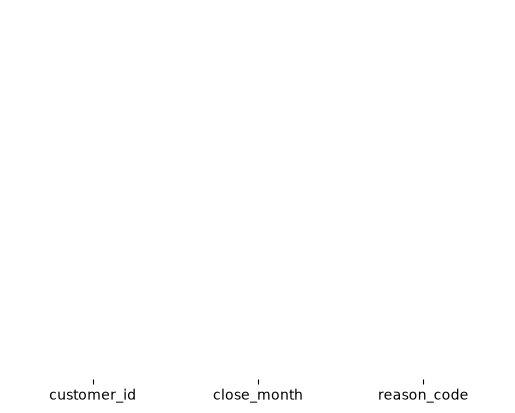

In [55]:
sns.heatmap(closure.isnull(), yticklabels=False, cbar=False, cmap="gray_r");

In [56]:
closure.info()

<class 'pandas.DataFrame'>
RangeIndex: 4023 entries, 0 to 4022
Data columns (total 3 columns):
 #   Column       Non-Null Count  Dtype
---  ------       --------------  -----
 0   customer_id  4023 non-null   int64
 1   close_month  4023 non-null   str  
 2   reason_code  4023 non-null   str  
dtypes: int64(1), str(2)
memory usage: 94.4 KB


In [57]:
closure['close_month'] = pd.PeriodIndex(closure['close_month'], freq='M')

In [58]:
closure.describe(include='all')

,customer_id,close_month,reason_code
count,4023.000000,4023,4023
unique,NaN,36,7
top,NaN,2025-01,Fees too high
freq,NaN,211,1268
mean,5963.338802,NaN,NaN
std,3998.635024,NaN,NaN
min,1.000000,NaN,NaN
25%,2585.500000,NaN,NaN
50%,5374.000000,NaN,NaN
75%,8905.000000,NaN,NaN


The closure month column extends into Jan 2025 (the most recent date available). This means any customers who have a flagged close_month can also be considered as churned.

In [59]:
spend = pd.read_csv('moneycraft_marketing_spend.csv')

spend.head()

,month,channel,spend_gbp
0,2022-01,Branch,7310.0
1,2022-01,Broker/IFA,4014.0
2,2022-01,Comparison Site,3162.0
3,2022-01,Online,3945.0
4,2022-01,Outbound,4899.0


## Spend nulls

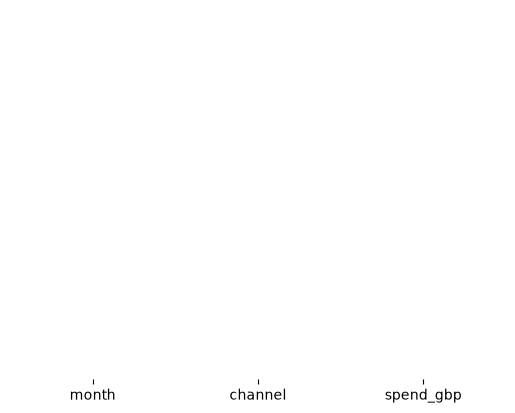

In [60]:
sns.heatmap(spend.isnull(), yticklabels=False, cbar=False, cmap="gray_r");

In [61]:
spend.info()

<class 'pandas.DataFrame'>
RangeIndex: 216 entries, 0 to 215
Data columns (total 3 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   month      216 non-null    str    
 1   channel    216 non-null    str    
 2   spend_gbp  216 non-null    float64
dtypes: float64(1), str(2)
memory usage: 5.2 KB


In [62]:
spend['month'] = pd.PeriodIndex(spend['month'], freq='M')

In [63]:
spend.describe(include='all')

,month,channel,spend_gbp
count,216,216,216.000000
unique,36,6,NaN
top,2022-01,Branch,NaN
freq,6,36,NaN
mean,NaN,NaN,6368.518519
std,NaN,NaN,2846.043225
min,NaN,NaN,1526.000000
25%,NaN,NaN,4413.500000
50%,NaN,NaN,6036.500000
75%,NaN,NaN,8040.000000


## Sanity-check the headline claims against the data

Headline claims ~15,700 fee paying customers.

In [64]:
accounts['customer_id'].nunique()

15732

In [65]:
accounts['monthly_fee'].sum()

np.int64(2190142)

## Consolidating the Data

In [66]:
combined = pd.merge(left=accounts, right=closure, how='left', on='customer_id')

combined.info()

<class 'pandas.DataFrame'>
RangeIndex: 179018 entries, 0 to 179017
Data columns (total 10 columns):
 #   Column               Non-Null Count   Dtype    
---  ------               --------------   -----    
 0   customer_id          179018 non-null  int64    
 1   month                179018 non-null  period[M]
 2   acquisition_channel  179018 non-null  str      
 3   region               179018 non-null  str      
 4   age_band             179018 non-null  str      
 5   account_tier         179018 non-null  str      
 6   monthly_fee          179018 non-null  int64    
 7   joined_on_promo      179018 non-null  bool     
 8   close_month          32883 non-null   period[M]
 9   reason_code          32883 non-null   str      
dtypes: bool(1), int64(2), period[M](2), str(5)
memory usage: 12.5 MB


In [67]:
combined.head()

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo,close_month,reason_code
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False,2022-07,Switched provider
1,2,2022-01,Online,London,55-64,Silver,11,False,NaT,NaN
2,3,2022-01,Branch,South East,25-34,Platinum,28,False,NaT,NaN
3,4,2022-01,Referral,London,25-34,Silver,0,True,NaT,NaN
4,5,2022-01,Comparison Site,South East,35-44,Silver,11,False,2022-11,Bereavement


In [68]:
combined['close_month'].max()

Period('2025-01', 'M')

In [69]:
# combined[combined['close_month'] == pd.Period('2025-01', 'M')]
combined[combined['customer_id'] == 376]


,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo,close_month,reason_code
640,376,2022-02,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
1179,376,2022-03,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
1989,376,2022-04,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
3059,376,2022-05,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
4392,376,2022-06,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
5973,376,2022-07,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
7825,376,2022-08,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
9977,376,2022-09,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
12410,376,2022-10,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown
15105,376,2022-11,Branch,Scotland,55-64,Classic,0,False,2025-01,Unknown


## Single Customer View

In [70]:
combined = combined.sort_values(['customer_id', 'month'], ascending=[True, True])

combined.head()

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo,close_month,reason_code
0,1,2022-01,Comparison Site,Scotland,25-34,Classic,0,False,2022-07,Switched provider
280,1,2022-02,Comparison Site,Scotland,25-34,Classic,0,False,2022-07,Switched provider
840,1,2022-03,Comparison Site,Scotland,25-34,Classic,0,False,2022-07,Switched provider
1664,1,2022-04,Comparison Site,Scotland,25-34,Classic,0,False,2022-07,Switched provider
2750,1,2022-05,Comparison Site,Scotland,25-34,Classic,0,False,2022-07,Switched provider


In [71]:
combined[combined['customer_id'] == 8]

,customer_id,month,acquisition_channel,region,age_band,account_tier,monthly_fee,joined_on_promo,close_month,reason_code
7,8,2022-01,Online,South East,45-54,Silver,11,False,NaT,NaN
287,8,2022-02,Online,South East,45-54,Silver,11,False,NaT,NaN
847,8,2022-03,Online,South East,45-54,Silver,11,False,NaT,NaN
1671,8,2022-04,Online,South East,45-54,Silver,11,False,NaT,NaN
2757,8,2022-05,Online,South East,45-54,Silver,11,False,NaT,NaN
4102,8,2022-06,Online,South East,45-54,Silver,11,False,NaT,NaN
5692,8,2022-07,Online,South East,45-54,Silver,11,False,NaT,NaN
7554,8,2022-08,Online,South East,45-54,Silver,11,False,NaT,NaN
9719,8,2022-09,Online,South East,45-54,Silver,11,False,NaT,NaN
12162,8,2022-10,Online,South East,45-54,Silver,11,False,NaT,NaN


In [72]:
grouped = combined.groupby('customer_id')

signup_month  = grouped['month'].min()               # their FIRST month
last_active   = grouped['month'].max()               # their LAST month
tenure_months = grouped['month'].count()             # how many months in total
reason_code = grouped['reason_code'].first()         # reason for churning (if available). For customers that have not churned, will be NaN
first_account_tier = grouped['account_tier'].first() # the account tier the customer joined on
last_account_tier = grouped['account_tier'].last()   # the account tier they ended with (if churned) / currently are using (if still active)
region = grouped['region'].last()                    # customers most recent region
channel = grouped['acquisition_channel'].first()     # the channel the customer was first acquired through
age_band = grouped['age_band'].last()                # the customers most recent age band
promo = grouped['joined_on_promo'].first()           # whether the customer joined on a promotion
close_month = grouped['close_month'].last()          # customer close month (if available)


total_revenue = grouped['monthly_fee'].sum()         # total revenue the customer has brought in over their tenure
max_fee = grouped['monthly_fee'].max()               # maximum fee paid during tenure

In [73]:
scv = pd.DataFrame({
    'signup_month' : signup_month,
    'last_active'  : last_active,
    'close_month'  : close_month,
    'reason_code'  : reason_code,
    'tenure_months': tenure_months,
    'channel'      : channel,
    'region'       : region,
    'age_band'     : age_band,
    'promo'        : promo,
    'first_account_tier' : first_account_tier,
    'last_account_tier' : last_account_tier,
    'max_fee'      : max_fee,
    'total_revenue': total_revenue
})

final_month = combined['month'].max()
scv['churned'] = scv['last_active'] < final_month    # create a churned flag - any customer ids with last active months less than '2024-12' are assumed to have churned

scv.head()

,signup_month,last_active,close_month,reason_code,tenure_months,channel,region,age_band,promo,first_account_tier,last_account_tier,max_fee,total_revenue,churned
customer_id,,,,,,,,,,,,,,
1,2022-01,2022-06,2022-07,Switched provider,6,Comparison Site,Scotland,25-34,False,Classic,Classic,0,0,True
2,2022-01,2024-12,NaT,NaN,36,Online,London,55-64,False,Silver,Platinum,28,595,False
3,2022-01,2024-12,NaT,NaN,36,Branch,South East,25-34,False,Platinum,Platinum,28,848,False
4,2022-01,2024-12,NaT,NaN,36,Referral,London,25-34,True,Silver,Silver,11,330,False
5,2022-01,2022-10,2022-11,Bereavement,10,Comparison Site,South East,35-44,False,Silver,Classic,11,33,True


In [74]:
# there are some customers which are incorrectly flagged as having not churned when considering the additional closure data
scv[(scv['churned'] == False) & ~(scv['close_month'].isnull())] 

,signup_month,last_active,close_month,reason_code,tenure_months,channel,region,age_band,promo,first_account_tier,last_account_tier,max_fee,total_revenue,churned
customer_id,,,,,,,,,,,,,,
376,2022-02,2024-12,2025-01,Unknown,35,Branch,Scotland,55-64,False,Classic,Classic,0,0,False
443,2022-02,2024-12,2025-01,Poor service,35,Outbound,South East,45-54,True,Classic,Silver,18,263,False
792,2022-03,2024-12,2025-01,Fees too high,34,Comparison Site,London,18-24,True,Silver,Gold,18,455,False
1233,2022-05,2024-12,2025-01,Switched provider,32,Outbound,London,25-34,False,Gold,Silver,18,506,False
1550,2022-06,2024-12,2025-01,Unknown,31,Comparison Site,South East,25-34,True,Silver,Classic,11,44,False
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15645,2024-12,2024-12,2025-01,Unknown,1,Comparison Site,London,25-34,True,Silver,Silver,0,0,False
15676,2024-12,2024-12,2025-01,Fees too high,1,Comparison Site,Wales & NI,45-54,True,Silver,Silver,0,0,False
15678,2024-12,2024-12,2025-01,Unknown,1,Online,North,25-34,False,Classic,Classic,0,0,False


In [75]:
# update all incorrect churned flags. any customer with a non-null close_month should be flagged as churned.

rows_to_update = scv[(scv['churned'] == False) & ~(scv['close_month'].isnull())].index

scv.loc[rows_to_update, 'churned'] = True

In [76]:
# verify rows have been updated
scv[(scv['churned'] == False) & ~(scv['close_month'].isnull())] 

,signup_month,last_active,close_month,reason_code,tenure_months,channel,region,age_band,promo,first_account_tier,last_account_tier,max_fee,total_revenue,churned
customer_id,,,,,,,,,,,,,,


In [77]:
scv.loc[376,:]

signup_month           2022-02
last_active            2024-12
close_month            2025-01
reason_code            Unknown
tenure_months               35
channel                 Branch
region                Scotland
age_band                 55-64
promo                    False
first_account_tier     Classic
last_account_tier      Classic
max_fee                      0
total_revenue                0
churned                   True
Name: 376, dtype: object

In [78]:
scv.head(10)

,signup_month,last_active,close_month,reason_code,tenure_months,channel,region,age_band,promo,first_account_tier,last_account_tier,max_fee,total_revenue,churned
customer_id,,,,,,,,,,,,,,
1,2022-01,2022-06,2022-07,Switched provider,6,Comparison Site,Scotland,25-34,False,Classic,Classic,0,0,True
2,2022-01,2024-12,NaT,NaN,36,Online,London,55-64,False,Silver,Platinum,28,595,False
3,2022-01,2024-12,NaT,NaN,36,Branch,South East,25-34,False,Platinum,Platinum,28,848,False
4,2022-01,2024-12,NaT,NaN,36,Referral,London,25-34,True,Silver,Silver,11,330,False
5,2022-01,2022-10,2022-11,Bereavement,10,Comparison Site,South East,35-44,False,Silver,Classic,11,33,True
6,2022-01,2024-12,NaT,NaN,36,Branch,South East,35-44,False,Gold,Gold,18,536,False
7,2022-01,2023-05,NaT,NaN,17,Outbound,Scotland,45-54,False,Silver,Silver,11,187,True
8,2022-01,2024-12,NaT,NaN,36,Online,South East,45-54,False,Silver,Gold,18,508,False
9,2022-01,2024-12,NaT,NaN,36,Online,North,35-44,False,Silver,Platinum,28,563,False


In [79]:
# some of the reason_codes are null values when they should be classified as 'Unknown'. we fill corresponding values as shown below
scv.loc[(scv['reason_code'].isna()) & ((scv['last_active'] < '2024-12') | (scv['churned'] == True)),
    'reason_code'] = 'Unknown'

In [80]:
scv.loc[7]

signup_month           2022-01
last_active            2023-05
close_month                NaT
reason_code            Unknown
tenure_months               17
channel               Outbound
region                Scotland
age_band                 45-54
promo                    False
first_account_tier      Silver
last_account_tier       Silver
max_fee                     11
total_revenue              187
churned                   True
Name: 7, dtype: object

In [81]:
scv.head(10)

,signup_month,last_active,close_month,reason_code,tenure_months,channel,region,age_band,promo,first_account_tier,last_account_tier,max_fee,total_revenue,churned
customer_id,,,,,,,,,,,,,,
1,2022-01,2022-06,2022-07,Switched provider,6,Comparison Site,Scotland,25-34,False,Classic,Classic,0,0,True
2,2022-01,2024-12,NaT,NaN,36,Online,London,55-64,False,Silver,Platinum,28,595,False
3,2022-01,2024-12,NaT,NaN,36,Branch,South East,25-34,False,Platinum,Platinum,28,848,False
4,2022-01,2024-12,NaT,NaN,36,Referral,London,25-34,True,Silver,Silver,11,330,False
5,2022-01,2022-10,2022-11,Bereavement,10,Comparison Site,South East,35-44,False,Silver,Classic,11,33,True
6,2022-01,2024-12,NaT,NaN,36,Branch,South East,35-44,False,Gold,Gold,18,536,False
7,2022-01,2023-05,NaT,Unknown,17,Outbound,Scotland,45-54,False,Silver,Silver,11,187,True
8,2022-01,2024-12,NaT,NaN,36,Online,South East,45-54,False,Silver,Gold,18,508,False
9,2022-01,2024-12,NaT,NaN,36,Online,North,35-44,False,Silver,Platinum,28,563,False


In [82]:
print("total customers: ", len(scv))

total customers:  15732


In [83]:
ever_paid = (scv['max_fee'] > 0).sum()
print("ever paid a fee: ", ever_paid)

ever paid a fee:  10571


In [84]:
# reconcile the brief's headline figures against scv
print("total customers :", len(scv))
print("ever paid a fee :", (scv['max_fee'] > 0).sum())
print("churned          :", scv['churned'].sum())
print("still active      :", (~scv['churned']).sum())

# fee revenue run-rate: fees billed in the final data month, annualised
last_fees = accounts.loc[accounts['month'] == final_month, 'monthly_fee'].sum()
print("\nfinal-month fees :", f"£{last_fees:,.0f}")
print("annualised  x12  :", f"£{last_fees*12:,.0f}", " <- the ~£1.6m headline")
print("total fees 36m   :", f"£{accounts['monthly_fee'].sum():,.0f}")
print("per-year average :", f"£{accounts['monthly_fee'].sum()/3:,.0f}")
print("total spend      :", f"£{spend['spend_gbp'].sum():,.0f}", " <- the ~£1.4m headline")

total customers : 15732
ever paid a fee : 10571
churned          : 6168
still active      : 9564

final-month fees : £132,016
annualised  x12  : £1,584,192  <- the ~£1.6m headline
total fees 36m   : £2,190,142
per-year average : £730,047
total spend      : £1,375,600  <- the ~£1.4m headline


In [85]:

churned = scv[scv['churned']]
print("churned total            :", len(churned))
print("with a closure row       :", churned['close_month'].notna().sum())
print("no closure row at all    :", churned['close_month'].isna().sum())
print("share with no row        :", f"{100*churned['close_month'].isna().mean():.1f}%")

print("\nreason_code in scv (post-fill):")
print(churned['reason_code'].value_counts())
print("\nraw closure table (pre-fill):")
print(closure['reason_code'].value_counts())

churned total            : 6168
with a closure row       : 4023
no closure row at all    : 2145
share with no row        : 34.8%

reason_code in scv (post-fill):
reason_code
Unknown               2780
Fees too high         1268
Poor service           887
Switched provider      623
Unhappy with perks     254
Moved abroad           210
Bereavement            146
Name: count, dtype: int64

raw closure table (pre-fill):
reason_code
Fees too high         1268
Poor service           887
Unknown                635
Switched provider      623
Unhappy with perks     254
Moved abroad           210
Bereavement            146
Name: count, dtype: int64


In [86]:
scv['reason_recorded'] = scv['close_month'].notna()   # True = we have a closure row

In [87]:

print("customers with >1 channel: ", int((accounts.groupby('customer_id')['acquisition_channel'].nunique() > 1).sum()))

print("\nby channel:\n", scv['channel'].value_counts())
print("\nfirst tier:\n", scv['first_account_tier'].value_counts())
print("promo share:", scv['promo'].value_counts(normalize=True).round(3).to_dict())
print("\nspend by channel:\n",
      spend.groupby('channel')['spend_gbp'].sum().sort_values(ascending=False).round(0))

customers with >1 channel:  0

by channel:
 channel
Comparison Site    4584
Online             3851
Branch             2481
Outbound           1962
Referral           1875
Broker/IFA          979
Name: count, dtype: int64

first tier:
 first_account_tier
Silver      5618
Classic     4652
Gold        3649
Platinum    1813
Name: count, dtype: int64
promo share: {False: 0.609, True: 0.391}

spend by channel:
 channel
Branch             377567.0
Online             269322.0
Outbound           239264.0
Broker/IFA         195020.0
Comparison Site    182406.0
Referral           112021.0
Name: spend_gbp, dtype: float64


In [ ]:
# considering these reasons to be unsatisfied with the service
unsatisfied = ['Poor service', 'Unhappy with perks', 'Fees too high']

counts = scv[scv['reason_code'].isin(unsatisfied)]['last_account_tier'].value_counts()
totals = scv['last_account_tier'].value_counts()

rate = (counts / totals * 100).round(1).sort_values(ascending=False)
print("unsatisfied churners as % of each tier:\n", rate)
print("\nraw counts:\n", counts)

unsatisfied churners as % of each tier:
 last_account_tier
Classic     21.7
Silver      16.5
Gold        12.3
Platinum     6.2
Name: count, dtype: float64

raw counts:
 last_account_tier
Classic     939
Silver      829
Gold        497
Platinum    144
Name: count, dtype: int64


In [89]:
#investigating the high churning rate for classic tier

isClassic = scv[(scv['last_account_tier'] == "Classic") & (scv['churned'])]
classicReasonCount = isClassic['reason_code'].value_counts()


In [92]:
print(classicReasonCount)

reason_code
Unknown              1281
Fees too high         548
Poor service          391
Switched provider     316
Moved abroad           87
Bereavement            71
Name: count, dtype: int64


In [99]:
fakeleaves = isClassic['first_account_tier'].value_counts()
print(fakeleaves)

first_account_tier
Classic     2360
Silver       312
Gold          20
Platinum       2
Name: count, dtype: int64


Majority of the customers who joined with classic left with classic too. This means that customers aren't disatissfied and churning, customers join for free and leave for free. Earlier we saw that `Fees too high` was the main driver for the high churning rate in Classic, however since majority of customers leave and join for free it introduces a fragility to the number from before. So lets see how the churning rate per tier changes if we do not consider `Fees too high` as a potential factor.

In [104]:
unsatisfied = ['Poor service', 'Unhappy with perks']

counts = scv[scv['reason_code'].isin(unsatisfied)]['last_account_tier'].value_counts()
totals = scv['last_account_tier'].value_counts()

rate = (counts / totals * 100).round(1).sort_values(ascending=False)
print(rate)

last_account_tier
Classic     9.0
Gold        8.0
Silver      6.1
Platinum    5.1
Name: count, dtype: float64


`Fees too high` was a label that did not make sense for Classic. When we included "Fees too high", Classic sat at **21.7%** with a significant gap compared to the other tiers. But even then Classic remains at the top of the tiers with the highest churning rate. The current results show that Gold and Classic are the two leakiest tiers for genuine dissatisfaction. Since we are working on 65% of the data which contained a reason to begin with, we could have noise within the data.

In [105]:
# ============================================================
# TIER × REASON × CHURN — consolidated analysis
# All rates are computed against tier SIZE (a rate, not a raw
# count) so a big tier doesn't look bad just for being big.
# ============================================================
ORDER  = ['Classic', 'Silver', 'Gold', 'Platinum']
totals = scv['last_account_tier'].value_counts()          # denominator = everyone ending on that tier

# --- A. "Unsatisfied" churn rate by tier -------------------
# Two definitions so we can stress-test the headline:
unsat_3 = ['Poor service', 'Unhappy with perks', 'Fees too high']   # original
unsat_2 = ['Poor service', 'Unhappy with perks']                    # 'Fees too high' dropped
#   (Fees too high is meaningless on the £0 Classic tier, so dropping
#    it tests whether Classic's lead was just a mislabelled-reason artefact)
rate_3 = (scv[scv['reason_code'].isin(unsat_3)]['last_account_tier'].value_counts() / totals * 100).reindex(ORDER)
diss   = (scv[scv['reason_code'].isin(unsat_2)]['last_account_tier'].value_counts() / totals * 100).reindex(ORDER)
print("Unsatisfied rate, 3 reasons (%):\n", rate_3.round(1), "\n")
print("Unsatisfied rate, fees dropped (%):\n", diss.round(1), "\n")

# --- B. Downgrade test: where did Classic leavers START? ---
# If most started on a PAID tier, the 'downgrade then leave' story is real.
origin = scv[(scv['last_account_tier'] == 'Classic') & scv['churned']]['first_account_tier'].value_counts().reindex(ORDER)
print("Starting tier of Classic leavers:\n", origin, "\n")
print("share who were free from day one: %.0f%%\n" % (100 * origin['Classic'] / origin.sum()))

# --- C. The honest metric: OVERALL churn rate by tier ------
# Uses the churned flag (known for ALL 15,732), so the 35%-incomplete
# reason table can't distort it. This is the number for the board.
churn = (scv.groupby('last_account_tier')['churned'].mean() * 100).reindex(ORDER)
print("Overall churn rate (%):\n", churn.round(1), "\n")

# --- D. Why the two metrics disagree: silent leavers -------
ch = scv[scv['churned']].copy()
ch['no_reason'] = ch['close_month'].isna()
silent = (ch.groupby('last_account_tier')['no_reason'].mean() * 100).reindex(ORDER)
print("Leavers with NO recorded reason (%):\n", silent.round(1), "\n")

# --- E. Do they leave fast or slow? Tenure of CHURNERS -----
# Churned customers only (an active customer's tenure means something different).
# Median is the headline (mean is dragged up by a tail of long-stayers).
tenure = scv[scv['churned']].groupby('last_account_tier')['tenure_months'].agg(['median', 'mean', 'count']).reindex(ORDER)
print("Tenure of churners (months):\n", tenure.round(1))

Unsatisfied rate, 3 reasons (%):
 last_account_tier
Classic     21.7
Silver      16.5
Gold        12.3
Platinum     6.2
Name: count, dtype: float64 

Unsatisfied rate, fees dropped (%):
 last_account_tier
Classic     9.0
Silver      6.1
Gold        8.0
Platinum    5.1
Name: count, dtype: float64 

Starting tier of Classic leavers:
 first_account_tier
Classic     2360
Silver       312
Gold          20
Platinum       2
Name: count, dtype: int64 

share who were free from day one: 88%

Overall churn rate (%):
 last_account_tier
Classic     62.3
Silver      42.2
Gold        25.3
Platinum    14.1
Name: churned, dtype: float64 

Leavers with NO recorded reason (%):
 last_account_tier
Classic     36.3
Silver      34.7
Gold        31.3
Platinum    33.5
Name: no_reason, dtype: float64 

Tenure of churners (months):
                    median  mean  count
last_account_tier                     
Classic               5.0   6.7   2694
Silver                7.0   8.4   2121
Gold                  8.0

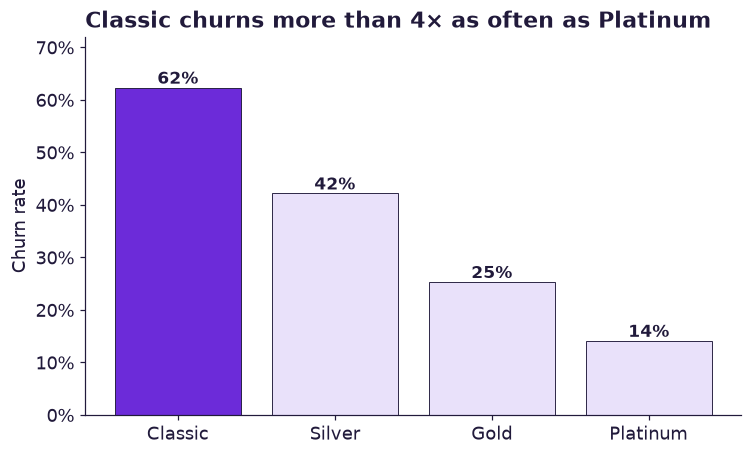

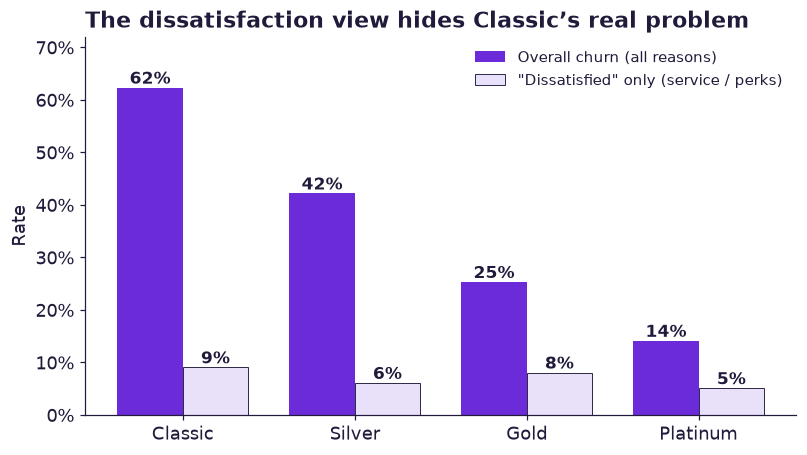

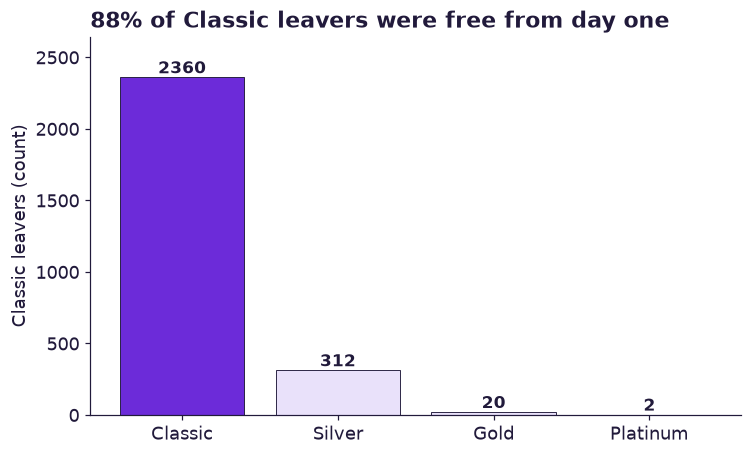

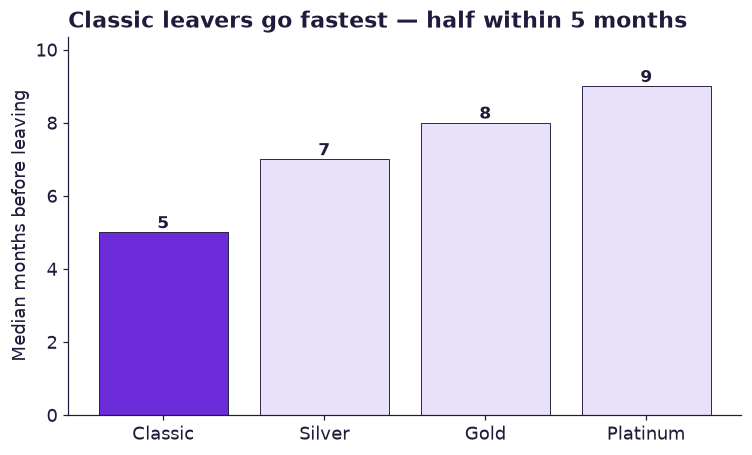

In [107]:
import numpy as np
from matplotlib.ticker import PercentFormatter

# ---- MoneyCraft brand palette (run once) ----
VIOLET  = '#6C2BD9'   # primary — the "look here" / focus colour
EVIOLET = '#8B5CF6'   # accent violet
INK     = '#211A3B'   # all text
MINT    = '#2DD4BF'   # held in reserve — positive signals only
LILAC   = '#E9E1FA'   # tint — de-emphasised / context bars
CLOUD   = '#F6F4FC'   # background (optional)

plt.rcParams.update({'font.size': 12, 'axes.spines.top': False, 'axes.spines.right': False,
                     'figure.dpi': 110, 'text.color': INK, 'axes.labelcolor': INK,
                     'xtick.color': INK, 'ytick.color': INK, 'axes.edgecolor': INK})

# Classic = focus (violet); every other tier = context (lilac with an ink edge)
foc = [VIOLET if t == 'Classic' else LILAC for t in ORDER]

def _label(ax, bars, fmt):
    for b in bars:
        ax.text(b.get_x() + b.get_width()/2, b.get_height(), fmt.format(b.get_height()),
                ha='center', va='bottom', fontsize=11, fontweight='bold', color=INK)

# CHART 1 — overall churn rate (the headline)
fig, ax = plt.subplots(figsize=(7, 4.3))
_label(ax, ax.bar(ORDER, churn, color=foc, edgecolor=INK, linewidth=.6), '{:.0f}%')
ax.yaxis.set_major_formatter(PercentFormatter()); ax.set_ylim(0, 72); ax.set_ylabel('Churn rate')
ax.set_title('Classic churns more than 4× as often as Platinum', fontweight='bold', loc='left')
plt.tight_layout(); plt.show()

# CHART 2 — dissatisfaction vs overall churn (why we trust churn)
fig, ax = plt.subplots(figsize=(7.5, 4.3)); x = np.arange(len(ORDER)); w = .38
_label(ax, ax.bar(x - w/2, churn, w, color=VIOLET, label='Overall churn (all reasons)'), '{:.0f}%')
_label(ax, ax.bar(x + w/2, diss,  w, color=LILAC, edgecolor=INK, linewidth=.6,
                  label='"Dissatisfied" only (service / perks)'), '{:.0f}%')
ax.set_xticks(x); ax.set_xticklabels(ORDER); ax.yaxis.set_major_formatter(PercentFormatter())
ax.set_ylim(0, 72); ax.set_ylabel('Rate'); ax.legend(frameon=False, fontsize=10)
ax.set_title('The dissatisfaction view hides Classic’s real problem', fontweight='bold', loc='left')
plt.tight_layout(); plt.show()

# CHART 3 — origin of Classic leavers (kills the downgrade story)
fig, ax = plt.subplots(figsize=(7, 4.3))
_label(ax, ax.bar(ORDER, origin.values, color=foc, edgecolor=INK, linewidth=.6), '{:.0f}')
ax.set_ylabel('Classic leavers (count)'); ax.set_ylim(0, origin.max()*1.12)
ax.set_title('88% of Classic leavers were free from day one', fontweight='bold', loc='left')
plt.tight_layout(); plt.show()

# CHART 4 — median tenure of churners (fast vs slow)
fig, ax = plt.subplots(figsize=(7, 4.3))
_label(ax, ax.bar(ORDER, tenure['median'].values, color=foc, edgecolor=INK, linewidth=.6), '{:.0f}')
ax.set_ylabel('Median months before leaving'); ax.set_ylim(0, tenure['median'].max()*1.15)
ax.set_title('Classic leavers go fastest — half within 5 months', fontweight='bold', loc='left')
plt.tight_layout(); plt.show()

could mention about a possible team that contacts customers who gave the reason "fees too high" even though they were on the Classic plan, as they might be mentioning the prices being too high which disencourages them from increasing their tier.

In [91]:
# save scv table to clipboard - this can be copied into an excel file and formatted as an csv
#scv.to_clipboard()